In [11]:
cd ../data/processed

c:\Users\admin\Documents\job_prediction\data\processed


c:\Users\admin\Documents\job_prediction\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [12]:
ls

 Volume in drive C is Windows-SSD
 Volume Serial Number is E879-C443

 Directory of c:\Users\admin\Documents\job_prediction\data\processed

06/01/2026  03:07 PM    <DIR>          .
06/01/2026  03:07 PM    <DIR>          ..
06/01/2026  03:07 PM           916,609 jobs_cleaned_full.csv
05/31/2026  11:25 PM                38 README.md
               2 File(s)        916,647 bytes
               2 Dir(s)  34,253,967,360 bytes free


In [13]:
!pip install pandas matplotlib seaborn

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 985.5 kB/s eta 0:00:08
   -- ------------------------------------- 0.5/8.2 MB 985.5 kB/s eta 0:00:08
   --- ------------------------------------ 0.8/8.2 MB 699.0 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.2 MB 699.0 kB/s eta 0:00:11
   -----

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
data = pd.read_csv('jobs_cleaned_full.csv')
print("Unique values per column: \n", data.nunique())
print("Missing values per column: \n", data.isnull().sum())

Unique values per column: 
 job_title                27
company_name           3147
location                  4
posted_date              62
salary_min               63
salary_max               97
salary_currency           1
job_type                  6
job_level                 5
experience_required      19
skills                 2803
source                    4
salary_missing            2
dtype: int64
Missing values per column: 
 job_title                 0
company_name              0
location                  0
posted_date               0
salary_min             3894
salary_max             3644
salary_currency        3582
job_type                  0
job_level               667
experience_required     945
skills                 1909
source                    0
salary_missing            0
dtype: int64


# EDA tiep theo
Kiem tra ty le thieu, phan pho bien luong, bien phan loai, va quan he giua luong va cac bien khac.

In [23]:
# Ty le thieu theo cot
missing_ratio = (data.isnull().mean() * 100).sort_values(ascending=False)
missing_ratio

salary_min             61.976763
salary_max             57.997772
salary_currency        57.010982
skills                 30.383575
experience_required    15.040586
job_level              10.615948
location                0.000000
company_name            0.000000
job_title               0.000000
posted_date             0.000000
job_type                0.000000
source                  0.000000
salary_missing          0.000000
dtype: float64

In [24]:
# Kiem tra logic luong
salary_invalid = data[(data["salary_min"].notnull()) & (data["salary_max"].notnull()) & (data["salary_min"] > data["salary_max"])]
salary_invalid.shape

(0, 13)

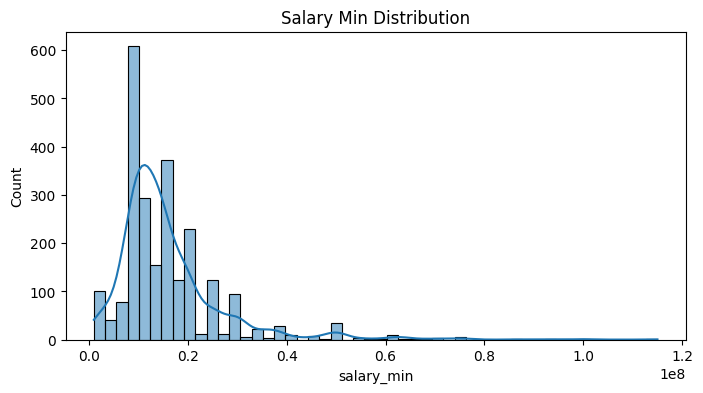

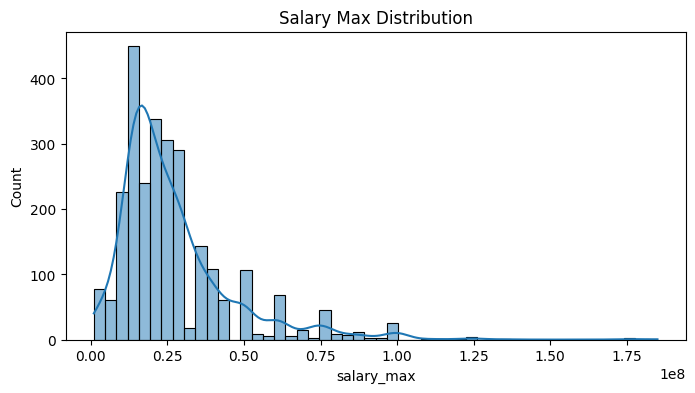

In [25]:
# Phan pho luong
plt.figure(figsize=(8, 4))
sns.histplot(data=data, x="salary_min", bins=50, kde=True)
plt.title("Salary Min Distribution")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=data, x="salary_max", bins=50, kde=True)
plt.title("Salary Max Distribution")
plt.show()

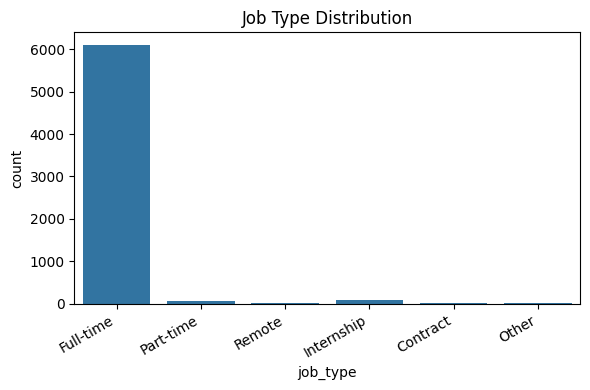

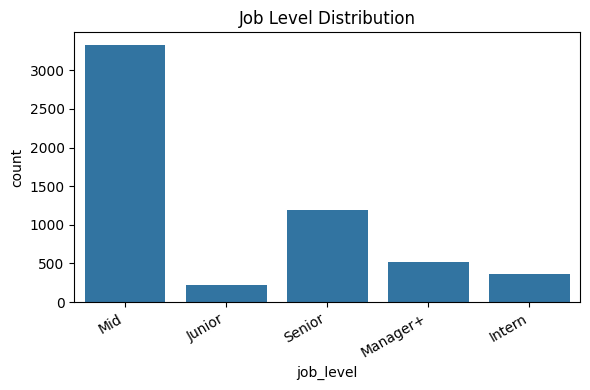

In [26]:
# Phan pho theo bien phan loai
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="job_type")
plt.title("Job Type Distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="job_level")
plt.title("Job Level Distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

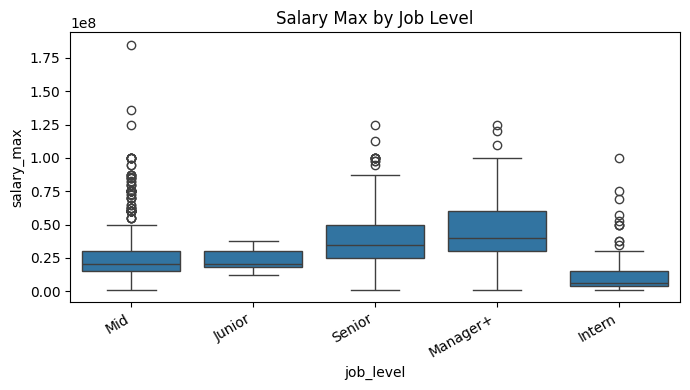

In [27]:
# Luong theo job_level
plt.figure(figsize=(7, 4))
sns.boxplot(data=data, x="job_level", y="salary_max")
plt.title("Salary Max by Job Level")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [28]:
# Top ky nang
skills_series = data["skills"].dropna().str.split(",")
skills_flat = skills_series.explode().str.strip().str.lower()
top_skills = skills_flat.value_counts().head(20)
top_skills

skills
ai            1258
sql            773
java           689
api            687
python         683
excel          637
agile          589
rest           520
security       515
ci/cd          418
aws            403
scrum          383
docker         382
linux          375
javascript     356
devops         353
erp            348
react          323
git            311
crm            308
Name: count, dtype: int64

# Nhan xet tu EDA
- Thieu du lieu cao o nhom luong: salary_min ~62%, salary_max ~58%, salary_currency ~57%. Can can nhac chi phan tich luong tren subset co luong, hoac tao bien co/khong luong.
- skills thieu ~30% cho thay su khac nhau theo nguon dang tin; nen kiem tra bias theo source/location.
- Phan pho luong lech phai, duoi dai va co outlier rat lon. Nen dung log-transform hoac cap theo percentile khi modeling.
- job_type lech manh ve Full-time; can can nhac gop nhom hoac class weight neu lam phan loai.
- job_level tap trung Mid va Senior; Intern va Junior it hon. Luong tang theo level la hop ly, nhung co nhieu outlier.
- Ky nang pho bien gom ai, sql, java, api, python, excel, agile, rest, security, ci/cd, aws, docker... cho thay du lieu pha tron giua data va software/devops.

In [ ]:
# Bang so sanh job_type x job_level
job_type_level = pd.crosstab(data["job_type"], data["job_level"], margins=True)
job_type_level

# Ty le theo hang
job_type_level_pct = pd.crosstab(data["job_type"], data["job_level"], normalize="index")
plt.figure(figsize=(8, 4))
sns.heatmap(job_type_level_pct, annot=True, fmt=".2f", cmap="Blues")
plt.title("Job Type x Job Level (row %)")
plt.tight_layout()
plt.show()